# Tarea 3. Gracida Salgado Angel David

Para evaluar qué tan bien sirven estas variables para predecir el diagnóstico,seguimos una estrategia de valor de umbral.

In [1]:

#abrimos el dataframe del cancer de mama con sklearn

import pandas as pd
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target # 0 = Maligno, 1 = Benigno
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [2]:
#df.isnull().sum() #no  hay valores vacíos
#df.info() #todos son valores numéricos, es decir no hay tipo NAN

1) Selecciona arbitrariamente tres variables del conjunto que tengan distinta
correlación con el diagnóstico:
(a) La primera variable debe tener una correlación cercana a cero.
(b) La segunda variable debe tener una correlación moderada, entre |0.3|
y |0.5|.
(c) La tercera variable debe tener una correlación alta, mayor que |0.75|.

In [3]:
#Utilizando el código dado en la clase 5 para encontrar la correlación de los datos con el target
df.corr()[['target']]

,target
mean radius,-0.730029
mean texture,-0.415185
mean perimeter,-0.742636
mean area,-0.708984
mean smoothness,-0.358560
mean compactness,-0.596534
mean concavity,-0.696360
mean concave points,-0.776614
mean symmetry,-0.330499
mean fractal dimension,0.012838


In [4]:
 #a) Escogemos la variable: <<symmetry error>> con correlación de 	0.006522

In [5]:
#b) Escogemos la variable: <<mean texture>> con correlación de -0.415185

In [6]:
#c) Escogemos la variable: <<mean concave points>> con correlación de -0.776614

2) Estudia las tres variables, puedes usar df[’VARIABLE’].describe()
para analizar su distribución y valores estadísticos.

In [7]:
#Vamos a aplicarles los análisis que vimos en clase

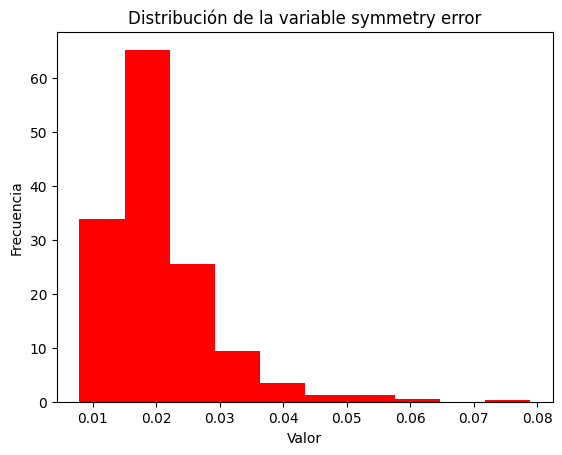

,symmetry error
count,569.000000
mean,0.020542
std,0.008266
min,0.007882
25%,0.015160
50%,0.018730
75%,0.023480
max,0.078950


In [8]:
import matplotlib.pyplot as plt

#a) baja correlación

plt.hist(df['symmetry error'],density=True,alpha=1,color="red")
plt.title('Distribución de la variable symmetry error')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()
df['symmetry error'].describe()

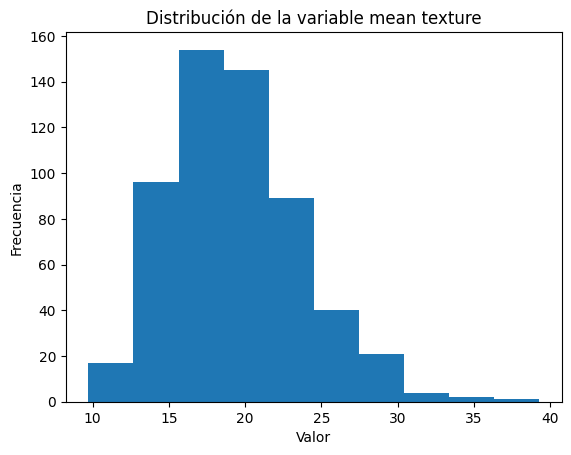

,mean texture
count,569.000000
mean,19.289649
std,4.301036
min,9.710000
25%,16.170000
50%,18.840000
75%,21.800000
max,39.280000


In [10]:
#b) media correlación

plt.hist(df['mean texture'])
plt.title('Distribución de la variable mean texture')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()
df['mean texture'].describe()

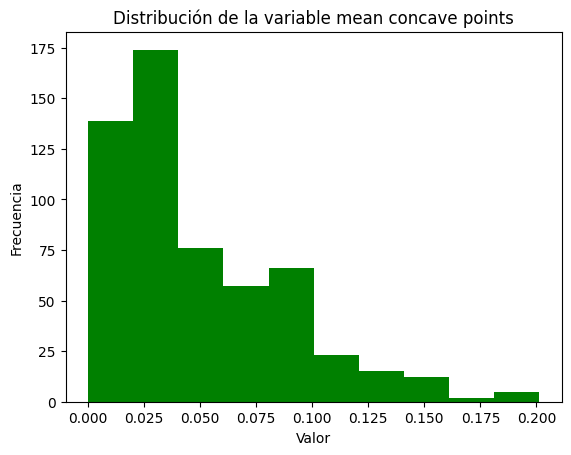

,mean concave points
count,569.000000
mean,0.048919
std,0.038803
min,0.000000
25%,0.020310
50%,0.033500
75%,0.074000
max,0.201200


In [11]:
#c) alta correlación
plt.hist(df['mean concave points'],color="green")
plt.title('Distribución de la variable mean concave points')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()

df['mean concave points'].describe()

3. Dibuja las variables para tumores malignos y benignos, y usa la estimación
de densidad de kernel (KDE) para visualizar su distribución. Escoge “a
ojo” un valor de umbral para cada variable que te ayudará a clasificar
los tumores como malignos o benignos.

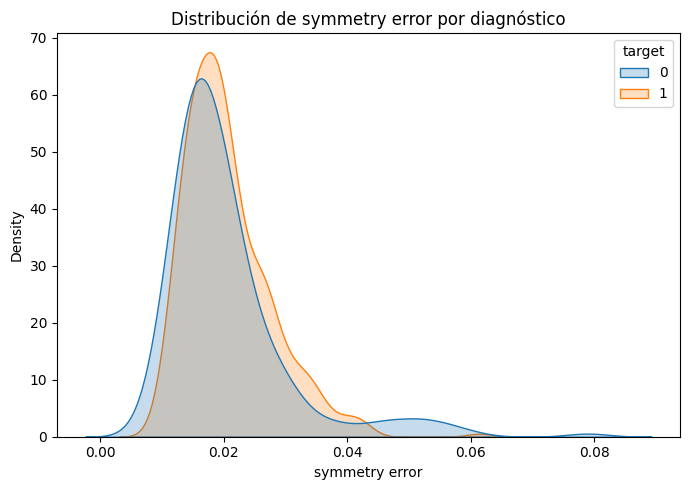

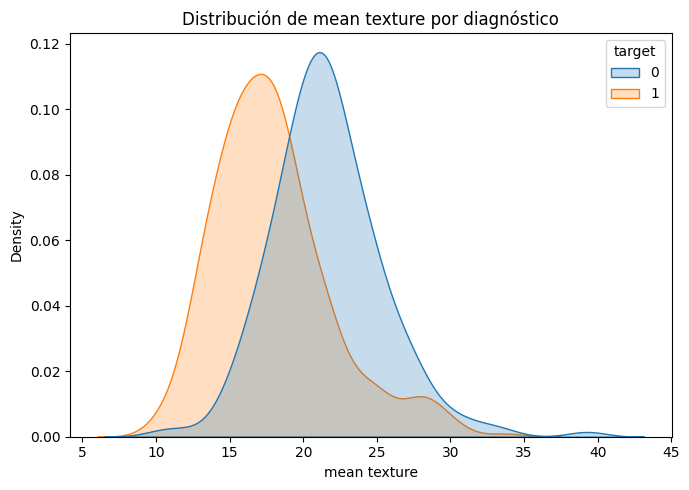

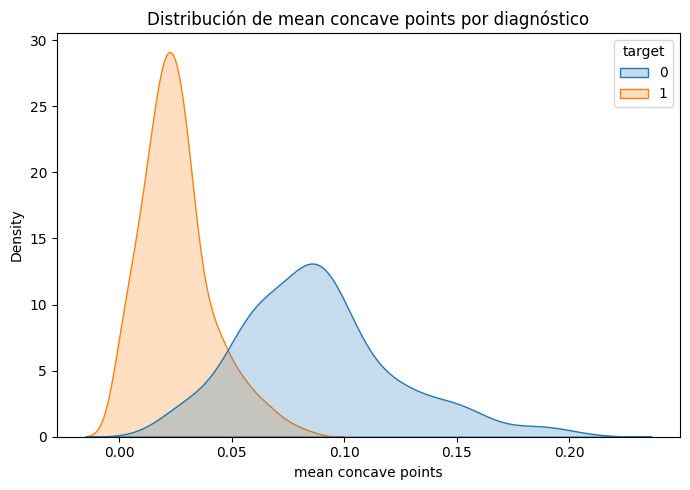

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

#maligno=0
#benigno=1
NOM=['symmetry error','mean texture','mean concave points']
for i in range(len(NOM)):
  var = NOM[i]
  plt.figure(figsize=(7, 5))
  sns.kdeplot(data=df, x=NOM[i], hue='target', fill=True, common_norm=False)
  plt.title(f'Distribución de {var} por diagnóstico')
  plt.xlabel(var)
  plt.tight_layout()
  plt.show()

In [13]:
#vamos a elegir los siguientes valores umbrales:

#Para a)  tienen cancer (0)< 0.02 < no tiene cancer (1)
#Para b)    no tiene (1) <20< tiene cancer (0)
#para c) no tiene cancer (1) < 0.05 < tiene cancer (0)

#Mi desicion de estos umbrales se basa en cocnluir que es peor mentirle a un paciente sobre no tener una enfermedad y que sí la tenga, que decirle que tiene esa enfermedad
#aunque no la tenga



4) El siguiente paso es evaluar qué tan bien podemos predecir si un tumor es
maligno o benigno dado un valor de umbral. Para ello, asigna tus propias
etiquetas de clasificación: esto significa que definas una nueva variable
df[’prediction’].

In [14]:
#Vamos a ver las predicciones para cada variable distinta

In [15]:


F1=[]
F2=[]
F3=[]
for i in df['symmetry error']:
  #print(i)
  if i<= 0.02:
    F1.append(0)
  elif i> 0.02:
    F1.append(1)

for i in df['mean texture']:
  if i<= 20:
     F2.append(1)
  elif i> 20:
    F2.append(0)


for i in df['mean concave points']:
  if i<= 0.05:
    F3.append(1)
  elif i> 0.05:
    F3.append(0)







#df['prediccion b']=F2

#print(F1)

In [16]:
df['prediccion a']=F1
df['prediccion b']=F2
df['prediccion c']=F3



5) Crea tus propias etiquetas de clasificación e imprime las primeras 30 filas con los valores reales del diagnóstico y las predicciones generadas. ¿Por qué hay casos con target = 0 (maligno) que tienen prediction = 1
(benigno)?

In [17]:
df.head(30)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,prediccion a,prediccion b,prediccion c
0,17.990,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,0.1622,0.6656,0.71190,0.26540,0.4601,0.11890,0,1,1,0
1,20.570,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,0.1238,0.1866,0.24160,0.18600,0.2750,0.08902,0,0,1,0
2,19.690,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,0.1444,0.4245,0.45040,0.24300,0.3613,0.08758,0,1,0,0
3,11.420,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,0.2098,0.8663,0.68690,0.25750,0.6638,0.17300,0,1,0,0
4,20.290,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,0.1374,0.2050,0.40000,0.16250,0.2364,0.07678,0,0,1,0
5,12.450,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,0.1791,0.5249,0.53550,0.17410,0.3985,0.12440,0,1,1,0
6,18.250,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,0.1442,0.2576,0.37840,0.19320,0.3063,0.08368,0,0,1,0
7,13.710,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,0.1654,0.3682,0.26780,0.15560,0.3196,0.11510,0,0,0,0
8,13.000,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,0.1703,0.5401,0.53900,0.20600,0.4378,0.10720,0,1,0,0
9,12.460,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,0.1853,1.0580,1.10500,0.22100,0.4366,0.20750,0,0,0,0


In [18]:
# Vemos que hay valores de target 0 que tienen una predicción (ya sea de a o b) de 1, esto se debe justamente al valor umbral escogido
#Ya que existen datos que correspondientes a un target de maligno que estan dentro del rango de valores de benigno (sobre todo en el caso de la variable menos correlacionada)
#Sin embargo, estas clasificaciones incorrectas disminuyen si las variables están muy correlacionadas, ya que la separación de los datos en las gráficas de la densidad
#del kernel son mayores.

6) Define FP (Falsos Positivos): casos donde el target real es 1 (benigno),
pero la predicción es 0 (maligno). Cuéntalos y encuentra cuántas predicciones fallaron para cada una de las tres variables.

In [19]:
#Listas de falsos positivos de a,b y c
FPa=[]
FPb=[]
FPc=[]
#usamos zip para buscar en dos columnas a la ves, esta función viene incluida en python.
for i,j in zip(df['target'],df['prediccion a']): #buscamos en la columna target y predicción de a, y se filtran los falsos positivos con la condición
  if i==1 and i!=j:
    FPa.append(i)

for i,j in zip(df['target'],df['prediccion b']):
  if i==1 and i!=j:
    FPb.append(i)

for i,j in zip(df['target'],df['prediccion c']):
  if i==1 and i!=j:
    FPc.append(i)



In [21]:
#Revismaos el tamaño de los falsos positivos (los contamos)
print("Falsos positivos para a=",len(FPa))
print("Falsos positivos para b",len(FPb))
print("Falsos positivos para c",len(FPc))


Falsos positivos para a= 205
Falsos positivos para b 83
Falsos positivos para c 30


In [22]:
df['target'].value_counts() #contamos los targets

,count
target,
1,357
0,212


In [23]:
Proporcion_A=len(FPa)/357
Proporcion_B=len(FPb)/357
Proporcion_C=len(FPc)/357

print("Los falsos positivos de a representan el ",Proporcion_A*100,"% de los casos benignos")
print("Los falsos positivos de b representan el ",Proporcion_B*100,"% de los casos benignos")
print("Los falsos positivos de c representan el ",Proporcion_C*100,"% de los casos benignos")

Los falsos positivos de a representan el  57.422969187675065 % de los casos benignos
Los falsos positivos de b representan el  23.249299719887954 % de los casos benignos
Los falsos positivos de c representan el  8.403361344537815 % de los casos benignos


Extra: Dibuja la matriz de confusión completa.Evalúa todas las 4 métricas
que hemos visto manualmente. ¿Tu modelo con el corte en el umbral que
escogiste es confiable?

In [24]:
#vamos a encontrar el resto de las entradas de la matriz de confusión: TN,FN,TP para casa una de las tres variables
#Si FP= casos donde el target es 1 (benigno) pero la predicción es 0 (maligno)
#Entonces:
#FN= casos donde el target real es 0 (maligno) pero la prediccion es 1 (benigno)
#TN= casos donde el target real es 1 (benigno) y la predicción es 1 (benigno)
#TP=casos donde el target real es 0 (maligno) y la prediccion es 0 (maligno)

#FN
FNa=[]
FNb=[]
FNc=[]
for i,j in zip(df['target'],df['prediccion a']): #buscamos en la columna target y predicción de a, y se filtran los falsos positivos con la condición
  if i==0 and i!=j:
    FNa.append(i)

for i,j in zip(df['target'],df['prediccion b']):
  if i==0 and i!=j:
    FNb.append(i)

for i,j in zip(df['target'],df['prediccion c']):
  if i==0 and i!=j:
    FNc.append(i)

#TN

TNa=[]
TNb=[]
TNc=[]
for i,j in zip(df['target'],df['prediccion a']): #buscamos en la columna target y predicción de a, y se filtran los falsos positivos con la condición
  if i==1 and i==j:
    TNa.append(i)

for i,j in zip(df['target'],df['prediccion b']):
  if i==1 and i==j:
    TNb.append(i)

for i,j in zip(df['target'],df['prediccion c']):
  if i==1 and i==j:
    TNc.append(i)

#TP

TPa=[]
TPb=[]
TPc=[]
for i,j in zip(df['target'],df['prediccion a']): #buscamos en la columna target y predicción de a, y se filtran los falsos positivos con la condición
  if i==0 and i==j:
    TPa.append(i)

for i,j in zip(df['target'],df['prediccion b']):
  if i==0 and i==j:
    TPb.append(i)

for i,j in zip(df['target'],df['prediccion c']):
  if i==0 and i==j:
    TPc.append(i)



In [25]:
import numpy as np
def matriz_confusion(TP,TN,FP,FN):
  return np.array([[TP,FN],[FP,TN]])

In [26]:
matriz_confusion("TP","TN","FP","FN")

array([['TP', 'FN'],
       ['FP', 'TN']], dtype='<U2')

In [27]:
print("matriz de confusión a =",matriz_confusion(len(TPa),len(TNa),len(FPa),len(FNa)),"\n") #para la variable a (poco correlacionada)
print("matriz de confusión b=",matriz_confusion(len(TPb),len(TNa),len(FPa),len(FNa))) #para la variable b (medianamente correlacionada)
print("matriz de confusión c=",matriz_confusion(len(TPc),len(TNc),len(FPc),len(FNc))) #para la variable c (altamente correlacionada)



matriz de confusión a = [[135  77]
 [205 152]] 

matriz de confusión b= [[142  77]
 [205 152]]
matriz de confusión c= [[193  19]
 [ 30 327]]


In [28]:
#Métricas
def accuracy(TP,TN,FP,FN):
  CC=TP+TN+FP+FN
  return (TP+TN)/CC

def precision(TP,FP):
  g=TP+FP
  a=TP/(g)
  return a

def recall(TP,FN):
  R=TP+FN
  return TP/R

def f1(precision,recall):
  FF=precision*recall
  HH=precision+recall
  return 2*FF/HH


In [29]:
#Para a)
print("Para a)")
print("accuracy=",accuracy(len(TPa),len(TNa),len(FPa),len(FNa)))
print("precision=",precision(len(TPa),len(FPa)))
print("recall=",recall(len(TPa),len(FNa)))
print("f1=",f1(precision(len(TPa),len(FPa)),recall(len(TPa),len(FNa))))
print("\n")
#Para b)
print("Para b)")
print("accuracy=",accuracy(len(TPb),len(TNb),len(FPb),len(FNb)))
print("precision=",precision(len(TPb),len(FPb)))
print("recall=",recall(len(TPb),len(FNb)))
print("f1=",f1(precision(len(TPb),len(FPb)),recall(len(TPb),len(FNb))))
print("\n")

#Para c)
print("Para c)")
print("accuracy=",accuracy(len(TPc),len(TNc),len(FPc),len(FNc)))
print("precision=",precision(len(TPc),len(FPc)))
print("recall=",recall(len(TPc),len(FNc)))
print("f1=",f1(precision(len(TPc),len(FPc)),recall(len(TPc),len(FNc))))
print("\n")

Para a)
accuracy= 0.5043936731107206
precision= 0.39705882352941174
recall= 0.6367924528301887
f1= 0.4891304347826087


Para b)
accuracy= 0.7311072056239016
precision= 0.6311111111111111
recall= 0.6698113207547169
f1= 0.6498855835240275


Para c)
accuracy= 0.9138840070298769
precision= 0.8654708520179372
recall= 0.910377358490566
f1= 0.8873563218390804




In [ ]:
#Después de ver las métricas, dado que el contexto es médico, el umbral escogido para las variables a y b ha sido perjudicial para el correcto diagnóstico
# de los tumores en el caso de symetry error (a) y mean texture (b)), por el contrario, la elección del umbral para la tercera variable ha sido favorable, pues muestra un recall
# de 0.91 lo que es muy beneficioso, pues indica pocos falsos negativos.